<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/lab3_lab%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1- gray scale image

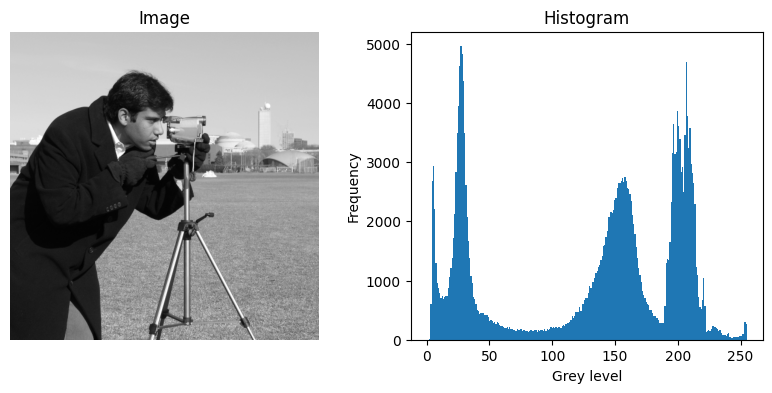

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

image = data.camera()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(image.flatten(), bins=256, range=(0,255))
plt.title("Histogram")
plt.xlabel("Grey level")
plt.ylabel("Frequency")

plt.show()

2-histogram equalision

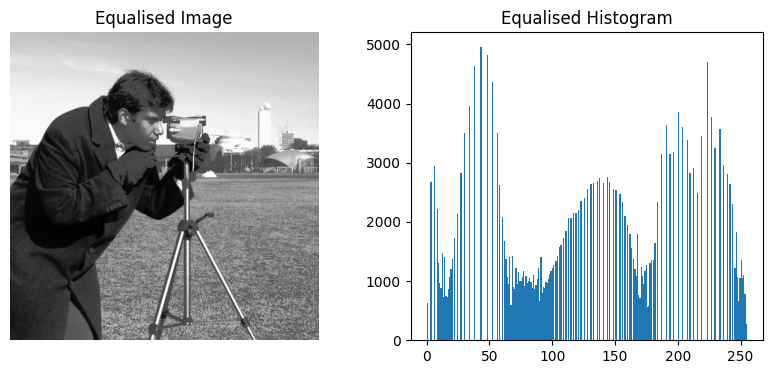

In [ ]:
def hist_equalise(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0,255))
    cdf = hist.cumsum()

    cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_norm = cdf_norm.astype(np.uint8)

    return cdf_norm[img]

equalised = hist_equalise(image)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(equalised, cmap='gray')
plt.title("Equalised Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(equalised.flatten(), bins=256, range=(0,255))
plt.title("Equalised Histogram")

plt.show()

3- smoothing


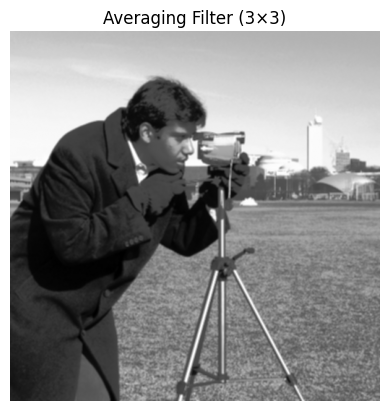

In [ ]:
from scipy.ndimage import uniform_filter

smoothed = uniform_filter(equalised, size=3)

plt.imshow(smoothed, cmap='gray')
plt.title("Averaging Filter (3×3)")
plt.axis('off')
plt.show()

4- sharpping

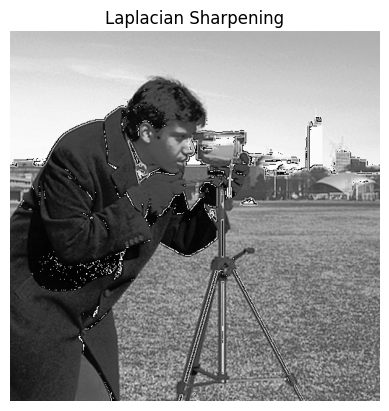

In [ ]:
from scipy.ndimage import laplace

lap = laplace(smoothed)
sharpened = smoothed - lap

plt.imshow(sharpened, cmap='gray')
plt.title("Laplacian Sharpening")
plt.axis('off')
plt.show()

5- final comparsion

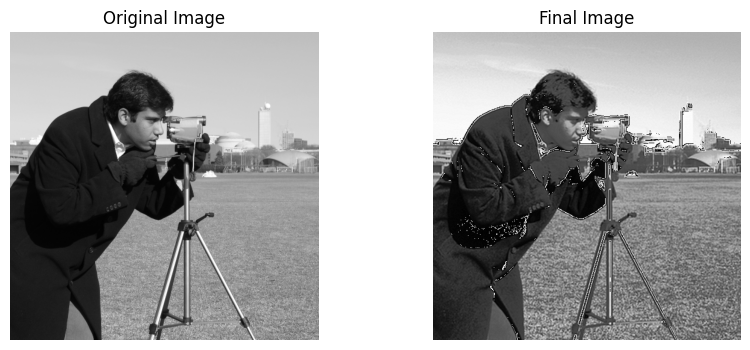

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharpened, cmap='gray')
plt.title("Final Image")
plt.axis('off')

plt.show()

1. Why does histogram equalisation sometimes over enhance images?
It can over increase contrast and amplify noise

2. Why is no single enhancement method sufficient in practice?
Different methods solve different problems, so combining them is necessary.

3. How does human perception influence a “good” enhancement?
Humans prefer images that look natural and visually clear.

# lab **4**

gray scale image


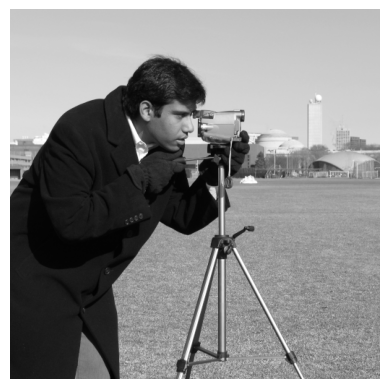

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera().astype(np.float32) / 255.0

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

Fourier Transform

In [2]:
F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

Lowpass Fillters(Ideal, Butterworth, gaussian)

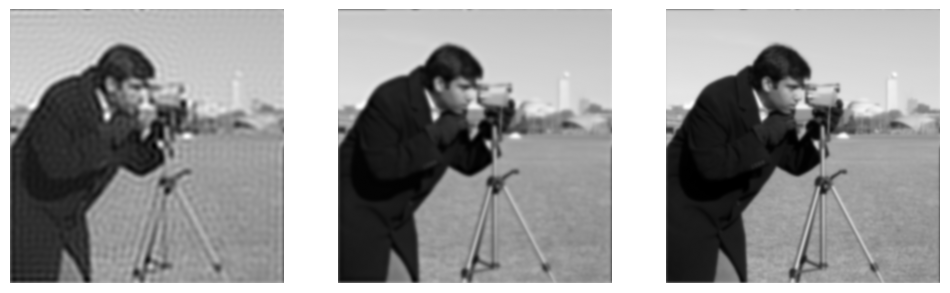

In [3]:
def ideal_lowpass(shape, D0):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    U, V = np.ogrid[:rows, :cols]
    D = np.sqrt((U - crow)**2 + (V - ccol)**2)
    return (D <= D0).astype(np.float32)

def butterworth_lowpass(shape, D0, n=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    U, V = np.ogrid[:rows, :cols]
    D = np.sqrt((U - crow)**2 + (V - ccol)**2)
    return 1 / (1 + (D / (D0 + 1e-12)) ** (2*n))

def gaussian_lowpass(shape, D0):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    U, V = np.ogrid[:rows, :cols]
    D2 = (U - crow)**2 + (V - ccol)**2
    return np.exp(-D2 / (2 * (D0**2)))

H_ideal = ideal_lowpass(img.shape, 35)
H_butt = butterworth_lowpass(img.shape, 35, 2)
H_gauss = gaussian_lowpass(img.shape, 35)

out_ideal = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_ideal)))
out_butt = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_butt)))
out_gauss = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_gauss)))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(out_ideal, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(out_butt, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(out_gauss, cmap="gray")
plt.axis("off")

plt.show()

Highpass & Sharpping

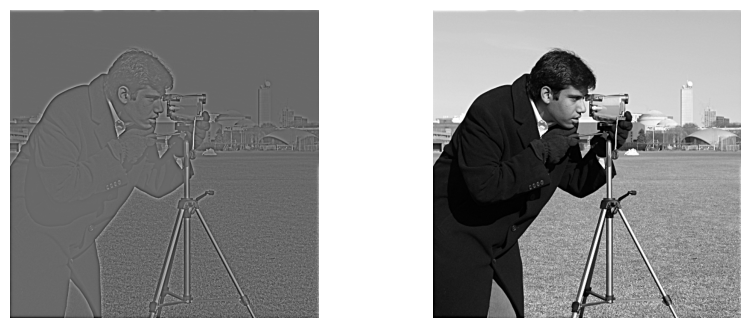

In [4]:
H_hp = 1 - H_gauss
out_hp = np.real(np.fft.ifft2(np.fft.ifftshift(F_shift * H_hp)))
sharp = np.clip(img + 0.7 * out_hp, 0, 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(out_hp, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sharp, cmap="gray")
plt.axis("off")

plt.show()

Perudic noise & Notch Filter

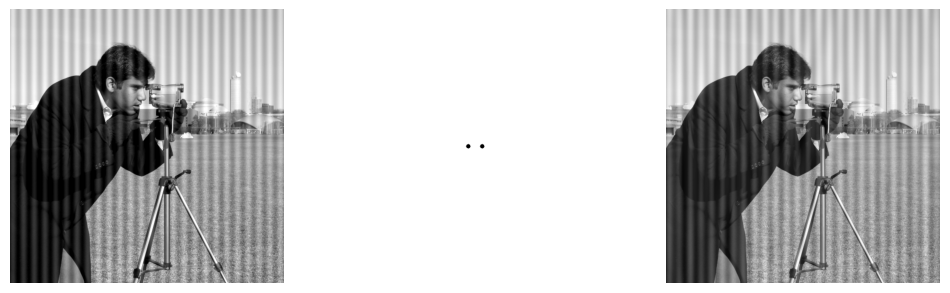

In [5]:
rows, cols = img.shape
x = np.arange(cols)
noise = 0.10 * np.sin(2 * np.pi * x / 20)
noise2d = np.tile(noise, (rows, 1)).astype(np.float32)

img_p = np.clip(img + noise2d, 0, 1)

Fp = np.fft.fftshift(np.fft.fft2(img_p))

Hn = np.ones_like(img_p, dtype=np.float32)
crow, ccol = rows//2, cols//2
notches = [(crow, ccol+13), (crow, ccol-13)]

rad = 4
U, V = np.ogrid[:rows, :cols]

for (u0, v0) in notches:
    D = np.sqrt((U-u0)**2 + (V-v0)**2)
    Hn[D <= rad] = 0

out_notch = np.real(np.fft.ifft2(np.fft.ifftshift(Fp * Hn)))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_p, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Hn, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(out_notch, cmap="gray")
plt.axis("off")

plt.show()

**Short Comparison**

Frequency interpretation:
Low pass smooths the image, while high pass highlights edges.

Filter shape and parameters:
Ideal has a sharp cutoff, Butterworth is smoother depending on n, Gaussian is the smoothest.

Ringing and blur trade off:
Ideal has strong ringing, Butterworth less, Gaussian the least and looks more natural

**Reflection Questions**

1. Why is frequency domain filtering more intuitive for periodic noise?
Because it appears as clear peaks in the spectrum, so its easy to remove

2. Why does sharp cutoff cause ringing?
Because abrupt changes create oscillations in the image (ringing)